# 04 — CNN Spatial Embeddings for Channel Head Coupling

This notebook adds a CNN-based spatial feature extractor to the classification pipeline.

**Pipeline:**
1. Pre-compute rasterized stream patches for all pairs in the master dataset
2. Train a shallow CNN (basin-level LOBO CV) to classify touching/non-touching
3. Extract 4-dim embeddings from the CNN's penultimate layer
4. Train XGBoost on 5 geometric + 4 CNN features (9 total)
5. Compare with the 5-feature geometric baseline

**Data leakage prevention:**
- CNN training uses strict **leave-one-basin-out (LOBO)** CV — each fold holds out an entire basin
- **Taiwan** is fully held out from all training (CNN + XGBoost) and used only for final evaluation
- CNN embeddings for each basin come from a model that **never saw that basin's data**
- Hard-negative filtering thresholds are computed per-fold on training data only

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader
from xgboost import XGBClassifier

from channel_heads import get_basin_config, list_basins
from channel_heads.cnn_features import CNN_FEATURE_COLS, merge_cnn_features
from channel_heads.cnn_model import (
    DEFAULT_EMBEDDING_DIM,
    OutletCNN,
    OutletPairDataset,
    encode_raster_onehot,
)
from channel_heads.config import CROPPED_DEMS_DIR, PROJECT_ROOT
from channel_heads.geometric_analysis import default_stream_loader
from channel_heads.rasterizer import (
    BACKGROUND,
    BRANCH_A,
    BRANCH_B,
    CONFLUENCE_MARKER,
    NUM_CLASSES,
    OTHER_STREAMS,
    precompute_raster_dataset,
    rasterize_outlet_pair,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Paths
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
MASTER_CSV = RESULTS_DIR / "master_dataset_v2.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Holdout basin — never used in training
HOLDOUT_BASIN = "taiwan"

# CNN hyperparameters
TARGET_SIZE = 128
EMBEDDING_DIM = 4
CNN_EPOCHS = 60
CNN_LR = 1e-3
CNN_WEIGHT_DECAY = 1e-4
CNN_BATCH_SIZE = 64
CNN_DROPOUT = 0.3
CNN_PATIENCE = 12

# XGBoost features
GEOM_FEATURES = [
    "orientation_diff_deg",
    "headhead_dist_norm",
    "apex_angle_deg",
    "strahler_order_diff",
    "proximity_profile_norm",
]

print(f"Master CSV: {MASTER_CSV}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Holdout basin: {HOLDOUT_BASIN}")
print(f"CNN: {CNN_EPOCHS} epochs max, patience={CNN_PATIENCE}")

Master CSV: /Users/guypi/Projects/channel-heads/data/results/master_dataset_v2.csv
Results dir: /Users/guypi/Projects/channel-heads/data/results
Holdout basin: taiwan
CNN: 60 epochs max, patience=12


## 1. Load Master Dataset

In [2]:
df_master = pd.read_csv(MASTER_CSV)
print(f"Master dataset: {df_master.shape[0]:,} rows × {df_master.shape[1]} columns")
print(f"Basins: {df_master['basin'].nunique()}")
print(f"Class balance: {df_master['y'].mean():.1%} touching")
print()

# Split into CV pool (16 basins) and holdout (Taiwan)
df_holdout = df_master[df_master["basin"] == HOLDOUT_BASIN].copy()
df_cv = df_master[df_master["basin"] != HOLDOUT_BASIN].copy()

print(f"CV pool: {len(df_cv):,} rows, {df_cv['basin'].nunique()} basins")
print(f"Holdout ({HOLDOUT_BASIN}): {len(df_holdout):,} rows")
print()
print("CV basins:", sorted(df_cv["basin"].unique()))

Master dataset: 5,922 rows × 23 columns
Basins: 17
Class balance: 39.1% touching

CV pool: 3,193 rows, 16 basins
Holdout (taiwan): 2,729 rows

CV basins: ['calnalpine', 'daqing', 'finisterre', 'humboldt', 'inyo', 'kammanasie', 'luliang', 'panamint', 'sakhalin', 'sierramadre', 'sierranevadaspain', 'toano', 'troodos', 'tsugaru', 'vallefertil', 'yoro']


## 2. Pre-compute Raster Patches

Rasterize each pair's outlet stream network into a 128×128 image with 5 classes:
- 0 = background, 1 = branch A, 2 = branch B, 3 = other streams, 4 = confluence marker

Each patch is canonically aligned (confluence at bottom, heads midpoint at top) and cropped to the pair's bounding box + 20% padding.

In [3]:
RASTER_DIR = RESULTS_DIR  # rasters saved under data/results/{basin}/rasters/

# Check if rasters are already pre-computed
raster_manifest_path = RESULTS_DIR / "raster_manifest.csv"
if raster_manifest_path.exists():
    print("Loading existing raster manifest...")
    df_raster = pd.read_csv(raster_manifest_path)
    n_valid = df_raster["raster_path"].notna().sum()
    print(f"  {n_valid}/{len(df_raster)} rasters available")
else:
    print("Pre-computing rasters for all pairs (this may take a while)...")
    df_raster = precompute_raster_dataset(
        master_csv=MASTER_CSV,
        output_dir=RASTER_DIR,
        dem_loader=default_stream_loader,
        target_size=TARGET_SIZE,
        threshold=300,
    )
    # Save manifest for reuse
    df_raster.to_csv(raster_manifest_path, index=False)
    n_valid = df_raster["raster_path"].notna().sum()
    print(f"Done. {n_valid}/{len(df_raster)} rasters computed successfully.")

# Filter to rows with valid rasters
df_with_rasters = df_raster[df_raster["raster_path"].notna()].copy().reset_index(drop=True)
print(f"\nUsable rows: {len(df_with_rasters):,} / {len(df_raster):,}")

Loading existing raster manifest...
  5922/5922 rasters available

Usable rows: 5,922 / 5,922


### 2.1 Visualize Sample Rasters

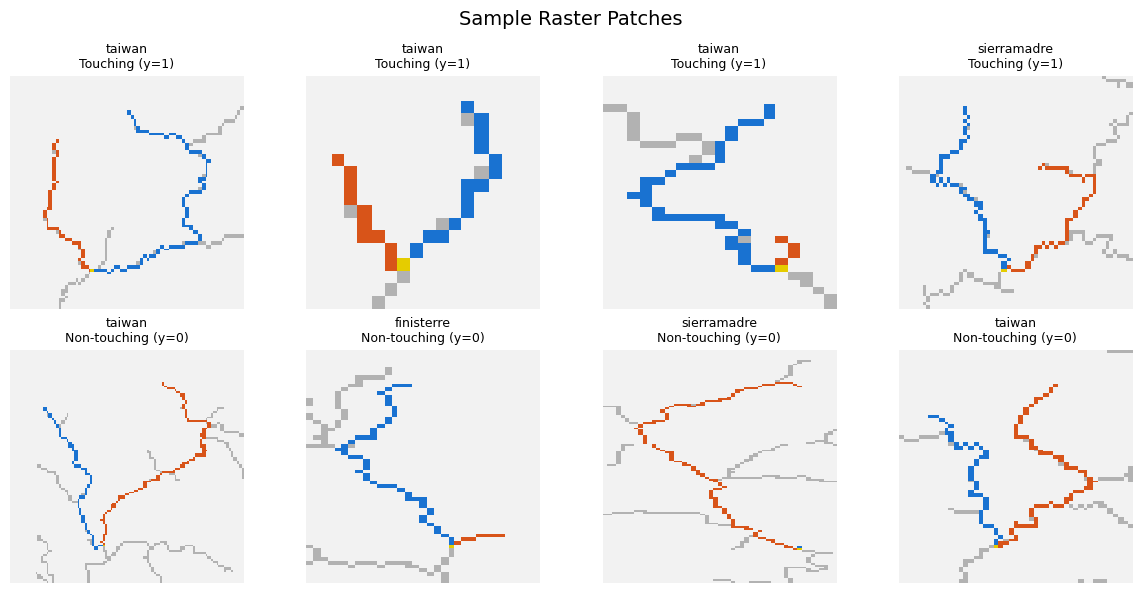

In [4]:
# Visualize a grid of sample rasters: touching vs non-touching
CLASS_COLORS = {
    BACKGROUND: [0.95, 0.95, 0.95],  # light gray
    BRANCH_A: [0.85, 0.33, 0.10],    # red-orange
    BRANCH_B: [0.10, 0.45, 0.82],    # blue
    OTHER_STREAMS: [0.70, 0.70, 0.70],  # gray
    CONFLUENCE_MARKER: [0.90, 0.80, 0.00],  # gold
}

def raster_to_rgb(raster):
    """Convert class-valued raster to RGB image for display."""
    h, w = raster.shape
    rgb = np.zeros((h, w, 3))
    for cls_val, color in CLASS_COLORS.items():
        mask = raster == cls_val
        for c in range(3):
            rgb[:, :, c][mask] = color[c]
    return rgb


n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
fig.suptitle("Sample Raster Patches", fontsize=14)

for label, row_axes, title in [
    (1, axes[0], "Touching (y=1)"),
    (0, axes[1], "Non-touching (y=0)"),
]:
    subset = df_with_rasters[df_with_rasters["y"] == label]
    samples = subset.sample(n=min(n_show, len(subset)), random_state=RANDOM_STATE)
    for i, (_, sample) in enumerate(samples.iterrows()):
        raster = np.load(sample["raster_path"])
        ax = row_axes[i]
        ax.imshow(raster_to_rgb(raster), interpolation="nearest")
        ax.set_title(f"{sample['basin']}\n{title}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
def train_cnn(
    df_train,
    df_val,
    n_epochs=CNN_EPOCHS,
    lr=CNN_LR,
    batch_size=CNN_BATCH_SIZE,
    embedding_dim=EMBEDDING_DIM,
    dropout=CNN_DROPOUT,
    weight_decay=CNN_WEIGHT_DECAY,
    patience=CNN_PATIENCE,
    device="cpu",
):
    """Train a CNN on df_train with early stopping on df_val.

    Returns
    -------
    model : OutletCNN
        Best model (eval mode).
    history : dict
        Training history with 'train_loss' and 'val_loss' lists.
    """
    ds_train = OutletPairDataset(df_train["raster_path"].tolist(), df_train["y"].values, augment=True)
    ds_val = OutletPairDataset(df_val["raster_path"].tolist(), df_val["y"].values, augment=False)
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    loader_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    model = OutletCNN(in_channels=NUM_CLASSES, embedding_dim=embedding_dim, dropout=dropout).to(device)

    n_pos = df_train["y"].sum()
    n_neg = len(df_train) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        # --- Train ---
        model.train()
        train_losses = []
        for images, labels in loader_train:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images).squeeze(1), labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validate ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in loader_val:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images).squeeze(1), labels).item())

        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses) if val_losses else float("nan")
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == n_epochs - 1 or patience_counter >= patience:
            print(f"  Epoch {epoch+1:3d}/{n_epochs}: "
                  f"train_loss={avg_train:.4f}, val_loss={avg_val:.4f}"
                  f"{' *best*' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model, history


def extract_embeddings(model, df_subset, device="cpu"):
    """Extract embeddings from a trained CNN. Returns array of shape (N, EMBEDDING_DIM)."""
    ds = OutletPairDataset(df_subset["raster_path"].tolist(), df_subset["y"].values, augment=False)
    loader = DataLoader(ds, batch_size=CNN_BATCH_SIZE, shuffle=False)

    all_emb = []
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            all_emb.append(model.embed(images.to(device)).cpu().numpy())
    return np.vstack(all_emb)


print("Training & extraction functions defined.")

Training & extraction functions defined.


## 3. Train CNN & Extract Embeddings

Train a single CNN on 90% of the non-Taiwan data (10% held out for early stopping),
then extract embeddings for **all** non-Taiwan rows and Taiwan with the same model.

In [6]:
# Split CV pool (excludes Taiwan)
df_cv_rasters = df_with_rasters[df_with_rasters["basin"] != HOLDOUT_BASIN].copy().reset_index(drop=True)
df_holdout_rasters = df_with_rasters[df_with_rasters["basin"] == HOLDOUT_BASIN].copy().reset_index(drop=True)

print(f"CV pool: {len(df_cv_rasters):,} rows ({df_cv_rasters['basin'].nunique()} basins)")
print(f"Holdout: {len(df_holdout_rasters):,} rows ({HOLDOUT_BASIN})")

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 90/10 split for early stopping
val_frac = 0.1
val_size = max(int(len(df_cv_rasters) * val_frac), 10)
perm = np.random.default_rng(RANDOM_STATE).permutation(len(df_cv_rasters))
val_idx = perm[:val_size]
train_idx = perm[val_size:]

df_train = df_cv_rasters.iloc[train_idx]
df_val = df_cv_rasters.iloc[val_idx]

print(f"\nCNN train: {len(df_train):,} rows ({df_train['y'].mean():.1%} touching)")
print(f"CNN val:   {len(df_val):,} rows ({df_val['y'].mean():.1%} touching)")
print(f"Training CNN ({CNN_EPOCHS} epochs max, patience={CNN_PATIENCE})...\n")

model, history = train_cnn(df_train, df_val, device=device)

# Extract embeddings for ALL CV rows + Taiwan using this single model
emb_cols = [f"emb_{i}" for i in range(EMBEDDING_DIM)]

print("\nExtracting embeddings...")
cv_embeddings = extract_embeddings(model, df_cv_rasters, device=device)
for i, col in enumerate(emb_cols):
    df_cv_rasters[col] = cv_embeddings[:, i]
print(f"  CV: {cv_embeddings.shape}")

holdout_embeddings = extract_embeddings(model, df_holdout_rasters, device=device)
for i, col in enumerate(emb_cols):
    df_holdout_rasters[col] = holdout_embeddings[:, i]
print(f"  Taiwan: {holdout_embeddings.shape}")

# Save model
final_model_path = MODELS_DIR / "cnn_outlet_final.pt"
torch.save(model.state_dict(), final_model_path)
print(f"\nSaved CNN: {final_model_path}")

CV pool: 3,193 rows (16 basins)
Holdout: 2,729 rows (taiwan)
Device: mps

CNN train: 2,874 rows (39.7% touching)
CNN val:   319 rows (37.6% touching)
Training CNN (60 epochs max, patience=12)...

  Epoch   1/60: train_loss=0.7673, val_loss=0.7638 *best*
  Epoch  11/60: train_loss=0.6088, val_loss=1.2245
  Epoch  21/60: train_loss=0.5467, val_loss=1.5700
  Epoch  31/60: train_loss=0.5148, val_loss=0.9946
  Epoch  34/60: train_loss=0.5176, val_loss=0.5709
  Early stopping at epoch 34 (no improvement for 12 epochs)

Extracting embeddings...
  CV: (3193, 4)
  Taiwan: (2729, 4)

Saved CNN: /Users/guypi/Projects/channel-heads/models/cnn_outlet_final.pt


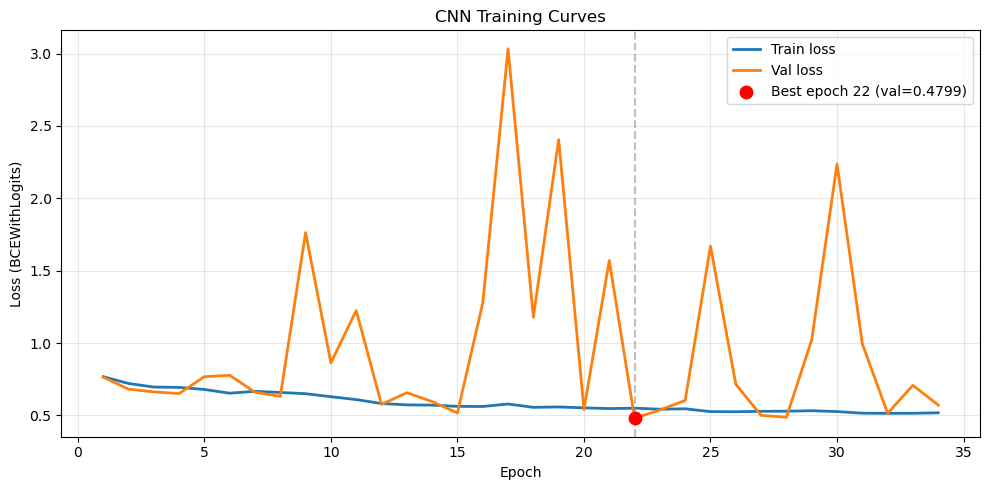

Trained 34 epochs, best at epoch 22


In [7]:
# Training curves
fig, ax = plt.subplots(figsize=(10, 5))
epochs = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs, history["train_loss"], label="Train loss", linewidth=2)
ax.plot(epochs, history["val_loss"], label="Val loss", linewidth=2)

# Mark best epoch
best_epoch = np.argmin(history["val_loss"]) + 1
best_val = min(history["val_loss"])
ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)
ax.scatter([best_epoch], [best_val], color="red", s=80, zorder=5,
           label=f"Best epoch {best_epoch} (val={best_val:.4f})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (BCEWithLogits)")
ax.set_title("CNN Training Curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Trained {len(history['train_loss'])} epochs, best at epoch {best_epoch}")

## 4. Taiwan Holdout Evaluation

Train XGBoost on all non-Taiwan data, test on Taiwan.
Both train and test embeddings come from the same CNN above.

In [8]:
# --- Taiwan Holdout: XGBoost evaluation ---

aug_features = GEOM_FEATURES + emb_cols

X_train_geom = df_cv_rasters[GEOM_FEATURES].values
X_train_aug = df_cv_rasters[aug_features].values
y_train_all = df_cv_rasters["y"].values

X_test_geom = df_holdout_rasters[GEOM_FEATURES].values
X_test_aug = df_holdout_rasters[aug_features].values
y_test = df_holdout_rasters["y"].values

n_pos = y_train_all.sum()
n_neg = len(y_train_all) - n_pos
spw = n_neg / max(n_pos, 1)

# Model A: Geometric only
xgb_geom = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss",
)
xgb_geom.fit(X_train_geom, y_train_all)
proba_geom = xgb_geom.predict_proba(X_test_geom)[:, 1]
pred_geom = (proba_geom >= 0.5).astype(int)

# Model B: Geometric + CNN
xgb_aug = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss",
)
xgb_aug.fit(X_train_aug, y_train_all)
proba_aug = xgb_aug.predict_proba(X_test_aug)[:, 1]
pred_aug = (proba_aug >= 0.5).astype(int)

# Results
print("=" * 60)
print("TAIWAN HOLDOUT EVALUATION")
print("=" * 60)
print(f"Test set: {len(y_test):,} rows, {y_test.mean():.1%} touching")
print()

if len(np.unique(y_test)) > 1:
    auc_geom = roc_auc_score(y_test, proba_geom)
    auc_aug = roc_auc_score(y_test, proba_aug)
    acc_geom = accuracy_score(y_test, pred_geom)
    acc_aug = accuracy_score(y_test, pred_aug)

    print(f"Model A (Geom only):     AUC={auc_geom:.3f}, Accuracy={acc_geom:.3f}")
    print(f"Model B (Geom + CNN):    AUC={auc_aug:.3f}, Accuracy={acc_aug:.3f}")
    print(f"Delta AUC:               {auc_aug - auc_geom:+.3f}")
    print()
    print("--- Classification Report (Geom + CNN) ---")
    print(classification_report(y_test, pred_aug, target_names=["not touching", "touching"]))
else:
    print("  Cannot compute AUC (single class in test set)")

TAIWAN HOLDOUT EVALUATION
Test set: 2,729 rows, 38.6% touching

Model A (Geom only):     AUC=0.772, Accuracy=0.701
Model B (Geom + CNN):    AUC=0.931, Accuracy=0.854
Delta AUC:               +0.159

--- Classification Report (Geom + CNN) ---
              precision    recall  f1-score   support

not touching       0.91      0.84      0.88      1675
    touching       0.78      0.87      0.82      1054

    accuracy                           0.85      2729
   macro avg       0.84      0.86      0.85      2729
weighted avg       0.86      0.85      0.86      2729



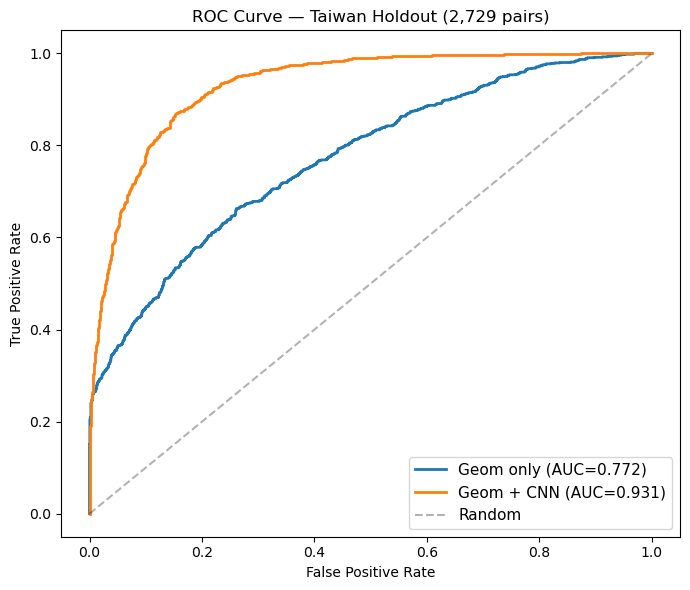

In [9]:
# ROC curves comparison (Taiwan holdout)
if len(np.unique(y_test)) > 1:
    fig, ax = plt.subplots(figsize=(7, 6))

    fpr_g, tpr_g, _ = roc_curve(y_test, proba_geom)
    fpr_a, tpr_a, _ = roc_curve(y_test, proba_aug)

    ax.plot(fpr_g, tpr_g, label=f"Geom only (AUC={auc_geom:.3f})", linewidth=2)
    ax.plot(fpr_a, tpr_a, label=f"Geom + CNN (AUC={auc_aug:.3f})", linewidth=2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — Taiwan Holdout ({len(y_test):,} pairs)")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

## 5. Feature Importance Analysis

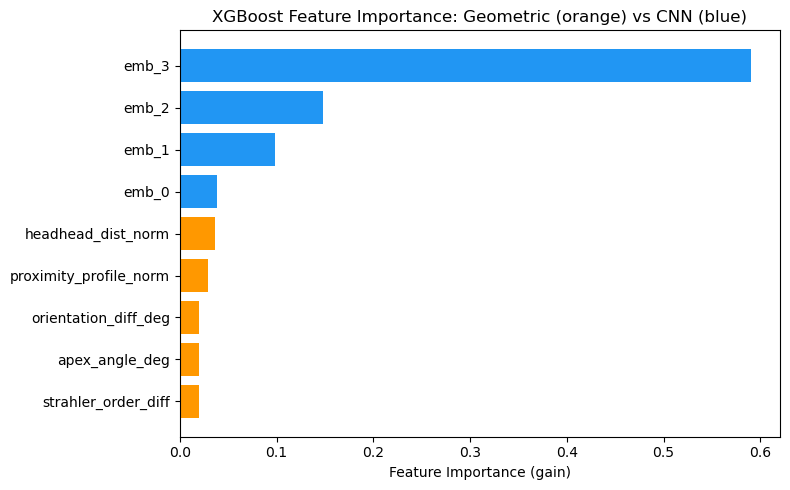


Feature importances:
  emb_3                     0.5908
  emb_2                     0.1477
  emb_1                     0.0978
  emb_0                     0.0379
  headhead_dist_norm        0.0366
  proximity_profile_norm    0.0295
  orientation_diff_deg      0.0202
  apex_angle_deg            0.0201
  strahler_order_diff       0.0194


In [10]:
# Feature importance from the augmented XGBoost model (trained on all CV data)
importances = xgb_aug.feature_importances_
feat_imp = pd.DataFrame({
    "feature": aug_features,
    "importance": importances,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2196F3" if f.startswith("emb_") else "#FF9800" for f in feat_imp["feature"]]
ax.barh(feat_imp["feature"], feat_imp["importance"], color=colors)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importance: Geometric (orange) vs CNN (blue)")
plt.tight_layout()
plt.show()

print("\nFeature importances:")
for _, row in feat_imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

## 6. Summary

| Metric | Geom Only (5 feat) | Geom + CNN (9 feat) |
|--------|-------------------|---------------------|
| Taiwan Holdout AUC | see above | see above |
| Taiwan Holdout Accuracy | see above | see above |

**Approach:** A single CNN is trained on all non-Taiwan data, then extracts embeddings
for both train (CV pool) and test (Taiwan). XGBoost trains and tests on embeddings
from the same embedding space — no misalignment across folds.